# Pulsar Star Detection using MLP
Implementation of a Multi-Layer Perceptron (MLP) to distinguish real pulsar stars from cosmic noise based on signal characteristics.

In [150]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import torch.nn as nn
import copy
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Analysis and Preprocessing

In [151]:
train_df = pd.read_csv('data\pulsar_data_train.csv')
test_df = pd.read_csv('data\pulsar_data_test.csv')

display(train_df.head())
display(train_df.describe())
display(test_df.head())
display(test_df.describe())

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,12528.000000,12528.000000,10793.000000,12528.000000,12528.000000,11350.000000,12528.000000,11903.000000,12528.000000
mean,111.041841,46.521437,0.478548,1.778431,12.674758,26.351318,8.333489,105.525779,0.092034
std,25.672828,6.801077,1.064708,6.208450,29.613230,19.610842,4.535783,107.399585,0.289085
min,5.812500,24.772042,-1.738021,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.871094,42.362222,0.024652,-0.188142,1.910535,14.404353,5.803063,35.199899,0.000000
50%,115.183594,46.931022,0.223678,0.203317,2.792642,18.412402,8.451097,83.126301,0.000000
75%,127.109375,50.979103,0.473125,0.932374,5.413253,28.337418,10.727927,139.997850,0.000000
max,189.734375,91.808628,8.069522,68.101622,222.421405,110.642211,34.539844,1191.000837,1.000000


,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,116.906250,48.920605,0.186046,-0.129815,3.037625,17.737102,8.122621,78.813405,NaN
1,75.585938,34.386254,2.025498,8.652913,3.765050,21.897049,7.048189,55.878791,NaN
2,103.273438,46.996628,0.504295,0.821088,2.244983,15.622566,9.330498,105.134941,NaN
3,101.078125,48.587487,1.011427,1.151870,81.887960,81.464136,0.485105,-1.117904,NaN
4,113.226562,48.608804,0.291538,0.292120,6.291806,26.585056,4.540138,21.708268,NaN


,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,5370.000000,5370.000000,4603.000000,5370.000000,5370.000000,4846.000000,5370.000000,5126.000000,0.0
mean,111.168917,46.615074,0.483676,1.751260,12.473587,26.425371,8.233724,102.869088,NaN
std,25.608635,6.940638,1.076893,6.072820,29.145134,19.384489,4.435683,104.748418,NaN
min,6.179688,24.791612,-1.876011,-1.764717,0.213211,7.370432,-2.721857,-1.964998,NaN
25%,101.041016,42.408020,0.030643,-0.189557,1.956522,14.555826,5.700461,33.817330,NaN
50%,114.757812,47.031304,0.227314,0.186468,2.830686,18.549670,8.383695,81.392046,NaN
75%,127.023438,51.133444,0.475056,0.918807,5.590301,28.681787,10.632265,136.893502,NaN
max,192.617188,98.778911,7.608370,65.385974,223.392141,109.712649,34.539844,1191.000837,NaN


- wartości cech mają bardzo różne zakresy -> potrzebne jest skalowanie

In [152]:
print("\n\nMissing values- train")
print(train_df.isnull().sum())

print("\n\nMissing values- test")
print(test_df.isnull().sum())

print("\n\nNumber of duplicate rows: ", train_df.duplicated().sum())

print("\n\nClasses size- noise, pulsar")
print(train_df['target_class'].value_counts())

print("\n\nPercentage")
print(train_df['target_class'].value_counts(normalize=True) * 100)




Missing values- train
 Mean of the integrated profile                     0
 Standard deviation of the integrated profile       0
 Excess kurtosis of the integrated profile       1735
 Skewness of the integrated profile                 0
 Mean of the DM-SNR curve                           0
 Standard deviation of the DM-SNR curve          1178
 Excess kurtosis of the DM-SNR curve                0
 Skewness of the DM-SNR curve                     625
target_class                                        0
dtype: int64


Missing values- test
 Mean of the integrated profile                     0
 Standard deviation of the integrated profile       0
 Excess kurtosis of the integrated profile        767
 Skewness of the integrated profile                 0
 Mean of the DM-SNR curve                           0
 Standard deviation of the DM-SNR curve           524
 Excess kurtosis of the DM-SNR curve                0
 Skewness of the DM-SNR curve                     244
target_class          

- braki w cechach
- tylko 9% to pulsary

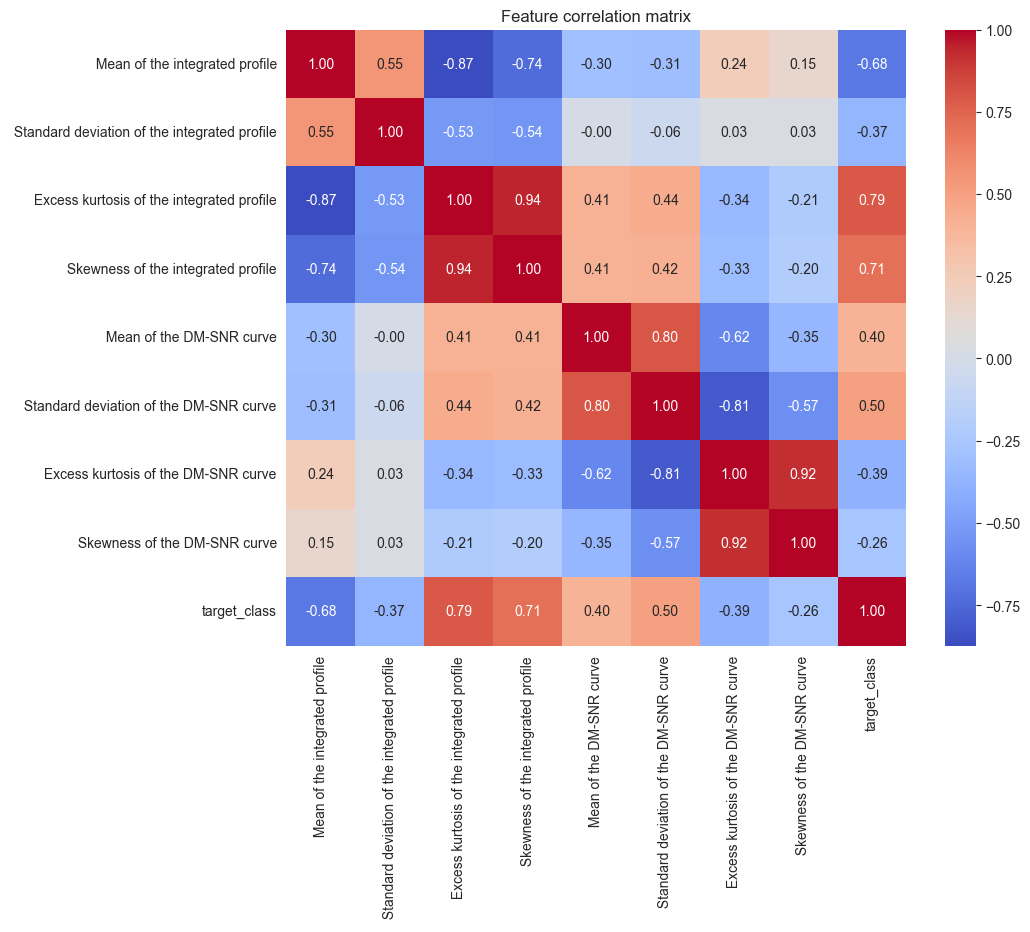

In [153]:
# macierz korelacji
# wartości bliskie 0 -> brak powiązania, bliskie 1 lub -1 -> bardzo silne powiązanie między cechami

plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature correlation matrix")
plt.show()

- największy wpływ na wykrywanie pulsarów -> kurtoza i średnia profilu
- wysoka korelacja między niektórymi cechami -> powtarzalność informacji (np Excess kurtosis i Skewness)

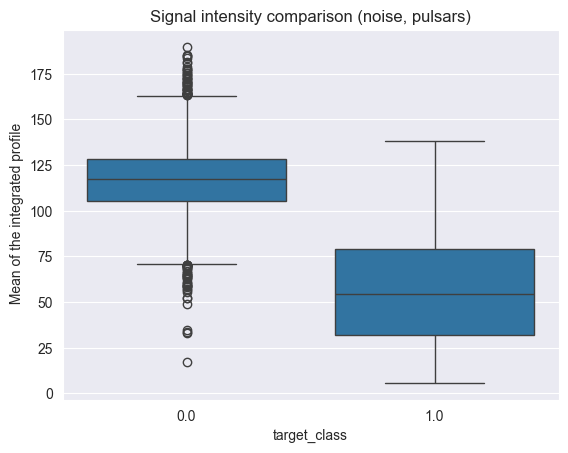

In [154]:
sns.boxplot(x='target_class', y=' Mean of the integrated profile', data=train_df)
plt.title("Signal intensity comparison (noise, pulsars)")
plt.show()

- pulsary (1) -> niższa średnia intensywność niż szum (0)

#### Preprocessing
- podział df_train na zbiór treningowy i walidacyjny do oceniania skuteczności modelu w czasie uczenia
- zastępowanie brakujących danych w cechach średnią
- standaryzacja danych -> x = (x - mean) / std

In [155]:
# Podzial danych
X = train_df.drop('target_class', axis=1)
y = train_df['target_class']

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [156]:
# Imputacja
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_raw)

X_val_imputed = imputer.transform(X_val_raw)
X_test_imputed = imputer.transform(test_df.drop('target_class', axis=1))

In [157]:
# Skalowanie
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

## Dataset and DataLoader

In [159]:
# Dataset i DataLoader
class PulsarData(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        
        self.y = None
        if y is not None:
            if hasattr(y, 'values'):
                y_data = y.values
            else:
                y_data = y
            self.y = torch.tensor(y_data, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

In [160]:
train_loader = DataLoader(PulsarData(X_train_scaled, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(PulsarData(X_val_scaled, y_val), batch_size=64)
test_loader = DataLoader(PulsarData(X_test_scaled), batch_size=64)

print(f"Trening: {len(X_train_scaled)} wierszy, Walidacja: {len(X_val_scaled)} wierszy")

Trening: 10022 wierszy, Walidacja: 2506 wierszy


## MLP Network Architecture

In [161]:
class PulsarNet(nn.Module):
    def __init__(self, input_size=8):
        super(PulsarNet, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)


## Training Loop

In [162]:
model = PulsarNet(input_size=8).to(device)
class_weights = torch.tensor([1.0, 3.0]).to(device) #wagi do zrownowazenia proporcji szumu - 91% do pulsarow - 9%

loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

epochs = 50
#early stopping
patience = 7 # ile epok bez poprawy
trigger_times = 0
best_val_loss = float('inf')
best_model_state = None

train_losses, val_losses = [], []
val_accuracies = []

for epoch in range(epochs):

    model.train()
    running_train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            v_loss = loss_fn(outputs, labels)
            running_val_loss += v_loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    #early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        trigger_times = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        trigger_times += 1
        if trigger_times >= patience:
            break

if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"wagi modelu z Val Loss= {best_val_loss:.4f}")


Epoch [1/50] | Train Loss: 0.2594 | Val Loss: 0.1326 | Val Acc: 97.77%
Epoch [2/50] | Train Loss: 0.1596 | Val Loss: 0.1271 | Val Acc: 97.77%
Epoch [3/50] | Train Loss: 0.1468 | Val Loss: 0.1228 | Val Acc: 97.81%
Epoch [4/50] | Train Loss: 0.1504 | Val Loss: 0.1203 | Val Acc: 98.12%
Epoch [5/50] | Train Loss: 0.1476 | Val Loss: 0.1210 | Val Acc: 97.73%
Epoch [6/50] | Train Loss: 0.1459 | Val Loss: 0.1188 | Val Acc: 98.00%
Epoch [7/50] | Train Loss: 0.1386 | Val Loss: 0.1212 | Val Acc: 98.12%
Epoch [8/50] | Train Loss: 0.1363 | Val Loss: 0.1176 | Val Acc: 98.16%
Epoch [9/50] | Train Loss: 0.1404 | Val Loss: 0.1192 | Val Acc: 98.08%
Epoch [10/50] | Train Loss: 0.1377 | Val Loss: 0.1170 | Val Acc: 98.20%
Epoch [11/50] | Train Loss: 0.1350 | Val Loss: 0.1157 | Val Acc: 98.12%
Epoch [12/50] | Train Loss: 0.1435 | Val Loss: 0.1159 | Val Acc: 98.20%
Epoch [13/50] | Train Loss: 0.1347 | Val Loss: 0.1154 | Val Acc: 98.08%
Epoch [14/50] | Train Loss: 0.1367 | Val Loss: 0.1171 | Val Acc: 98.12%
E

## Evaluation and Results

#### Error Matrix

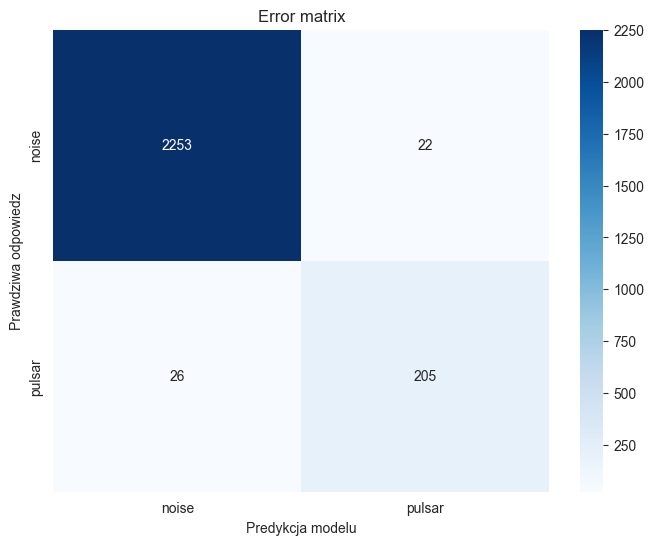

Wyniki walidacji
              precision    recall  f1-score   support

       noise       0.99      0.99      0.99      2275
      pulsar       0.90      0.89      0.90       231

    accuracy                           0.98      2506
   macro avg       0.95      0.94      0.94      2506
weighted avg       0.98      0.98      0.98      2506



In [164]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['noise', 'pulsar'], yticklabels=['noise', 'pulsar'])

plt.title(f'Error matrix')
plt.xlabel('Predykcja modelu')
plt.ylabel('Prawdziwa odpowiedz')
plt.show()

print("Wyniki walidacji")
print(classification_report(y_true, y_pred, target_names=['noise', 'pulsar']))

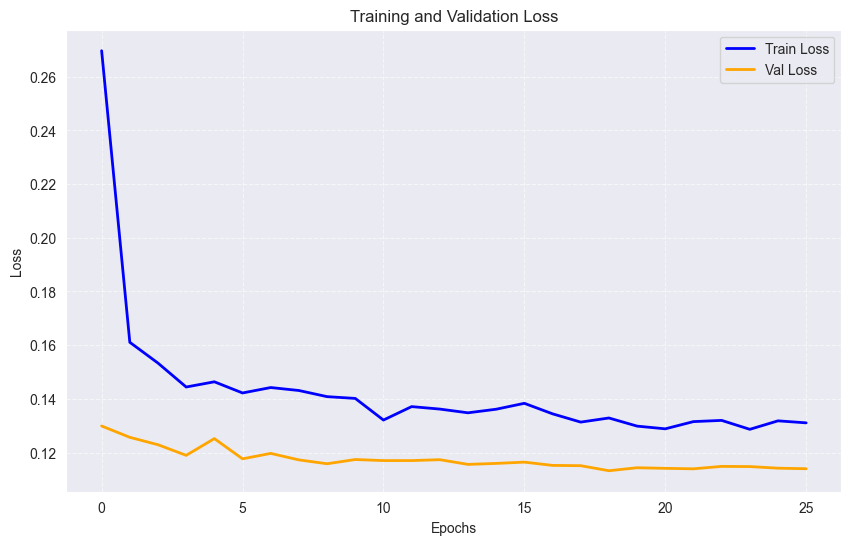

In [146]:
plt.figure(figsize=(10, 6))

plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Val Loss', color='orange', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- niezbalansowane dane: 91% szum, 9% pulsary -> nie można oceniać modelu po accuracy

Metryki:
- recall -> jaki procent pulsarów (szumu) wykrył model
- precision -> ile wskazanych pulsarów (szumu) to rzeczywiscie pulsary(szum)
- f1-score -> metryka laczaca precison i recall (ich srednia harmoniczna 2 * (p * r / (p + r)))

## Predictions for Test Set

In [165]:
model.eval()
test_predictions = []

with torch.no_grad():
    for inputs in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        test_predictions.extend(predicted.cpu().numpy())

test_df['target_class'] = test_predictions
display(test_df.head())
print("\nDistribution of predicted classes:")
print(test_df['target_class'].value_counts())

# test_df.to_csv('pulsar_predictions_results.csv', index=False)

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,116.906250,48.920605,0.186046,-0.129815,3.037625,17.737102,8.122621,78.813405,0
1,75.585938,34.386254,2.025498,8.652913,3.765050,21.897049,7.048189,55.878791,1
2,103.273438,46.996628,0.504295,0.821088,2.244983,15.622566,9.330498,105.134941,0
3,101.078125,48.587487,1.011427,1.151870,81.887960,81.464136,0.485105,-1.117904,1
4,113.226562,48.608804,0.291538,0.292120,6.291806,26.585056,4.540138,21.708268,0



Distribution of predicted classes:
target_class
0    4885
1     485
Name: count, dtype: int64
